**Video processing**

In [3]:
import pandas as pd

# 1. Load your feature file
file_path = "/content/drive/MyDrive/Embedding /videos_face_embeddings.csv"
df = pd.read_csv(file_path)

# 2. Create the Counter based on the 'Link' column
# factorize() assigns a unique ID to each unique value it finds in the column
df['Counter'], _ = pd.factorize(df['Link'])

# Optional: If you want the counter to start from 1 instead of 0
df['Counter'] = df['Counter'] + 1

# 3. Reorder columns so 'Counter' is at the front (easier to read)
cols = ['Counter'] + [c for c in df.columns if c != 'Counter']
df = df[cols]

# 4. Save the updated file
# Replace the old file or save as a new one to be safe
output_path = "/content/drive/MyDrive/Embedding /videos_face_embeddings_final.csv"
df.to_csv(output_path, index=False)

print(f"Successfully added Counter column! Total unique videos: {df['Counter'].nunique()}")
print(df.head())

Successfully added Counter column! Total unique videos: 8576
   Counter                                               Link  Frame Label  \
0        1  /content/drive/MyDrive/1FPS_video/Anger_39_202...      0     A   
1        1  /content/drive/MyDrive/1FPS_video/Anger_39_202...      0     A   
2        1  /content/drive/MyDrive/1FPS_video/Anger_39_202...      1     A   
3        1  /content/drive/MyDrive/1FPS_video/Anger_39_202...      2     A   
4        1  /content/drive/MyDrive/1FPS_video/Anger_39_202...      3     A   

        E_0       E_1       E_2       E_3       E_4       E_5  ...     E_502  \
0 -0.046640 -0.025821 -0.110452 -0.039396 -0.009209 -0.085977  ...  0.027599   
1 -0.026044 -0.067772 -0.057354 -0.025335  0.003112 -0.036060  ... -0.076964   
2 -0.028855 -0.043847 -0.111388 -0.032702 -0.028534 -0.086945  ...  0.026986   
3 -0.040428 -0.040788 -0.084767 -0.039417 -0.040225 -0.089461  ...  0.003516   
4 -0.058993 -0.039376 -0.135422 -0.030933 -0.029387 -0.078001  ...  0.

In [1]:
import pandas as pd

# Load your file
df = pd.read_csv("/content/drive/MyDrive/Embedding /videos_face_embeddings_final.csv")

# 1. See all unique labels and their row counts
print("--- Label Distribution ---")
print(df['Label'].value_counts())

# 2. Check for hidden spaces or case issues
print("\n--- Raw Unique Values ---")
print(df['Label'].unique())

# 3. Quick count of unique categories
print(f"\nTotal unique labels found: {df['Label'].nunique()}")

print("total rows: ",len(df))

--- Label Distribution ---
Label
A    25433
S    22041
H    21799
N    18472
L    14425
s       18
U       12
Name: count, dtype: int64

--- Raw Unique Values ---
['A' 'H' 'L' 'N' 'S' 's' 'U']

Total unique labels found: 7
total rows:  102200


In [2]:
!pip install torchinfo

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
import torchinfo
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

In [4]:
import torch
import torch.nn as nn

class VideoEmotionRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout):
        super(VideoEmotionRNN, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc_out = nn.Linear(hidden_dim, num_classes)  # Ensure correct dimensions for fc_out
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x, mask=None, extract_embeddings=False):
        # x shape: (batch_size, num_frames, input_dim)

        lstm_out, (hn, cn) = self.lstm(x)  # lstm_out shape: (batch_size, num_frames, hidden_dim)

        if extract_embeddings:
            return lstm_out.mean(dim=1)  # Return embeddings for extraction

        # Pooling or selecting the final hidden state
        output = lstm_out.mean(dim=1)  # Average over the time dimension (temporal pooling)

        # Pass through the output layer
        output = self.fc_out(output)  # Shape: (batch_size, num_classes)
        output = self.softmax(output)  # Apply softmax for classification

        return output

In [5]:
def preprocess_data(csv_path, max_len=15, input_dim=512):
    # 1. Load data
    data = pd.read_csv(csv_path)

    # 2. Cleanup Labels (Merges 's' and 'S', removes 'U')
    data['Label'] = data['Label'].str.strip().str.upper()
    core_emotions = ['A', 'H', 'L', 'N', 'S']
    data = data[data[ 'Label' ].isin(core_emotions)]

    # 3. CRITICAL: Sort feature columns (E_1, E_2... E_512)
    # Without this, pandas might read columns as E_1, E_10, E_100...
    feature_columns = [col for col in data.columns if col.startswith('E_')]
    feature_columns.sort(key=lambda x: int(x.split('_')[1]))

    # 4. Processing groups
    grouped = data.groupby('Counter')
    video_features, video_labels, video_links = [], [], []

    for counter, group in grouped:
        features = group[feature_columns].values
        label = group['Label'].iloc[0]

        # We store the CLEAN name (no path/extension) for easy merging later
        raw_link = group['Link'].iloc[0]

        # Padding/Truncation Logic
        features_tensor = torch.tensor(features, dtype=torch.float32)
        if len(features_tensor) < max_len:
            pad_len = max_len - len(features_tensor)
            padding = torch.zeros((pad_len, input_dim))
            features_final = torch.cat((features_tensor, padding), dim=0)
        else:
            features_final = features_tensor[:max_len]

        video_features.append(features_final)
        video_labels.append(label)
        video_links.append(raw_link)

    # 5. Final Tensor Conversion
    video_features = torch.stack(video_features)

    label_encoder = LabelEncoder()
    video_labels_encoded = torch.tensor(label_encoder.fit_transform(video_labels))

    # Mapping output for your thesis documentation
    label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
    print("Label encoding mapping:", label_mapping)

    return video_features, video_labels_encoded, video_links

In [6]:
def prepare_data_loaders(video_features, video_labels, batch_size, test_size=0.2):
    # Split only features and labels
    X_train, X_test, y_train, y_test = train_test_split(
        video_features,
        video_labels,
        test_size=test_size,
        random_state=42,
        stratify=video_labels
    )

    # Create datasets
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Return only the loaders
    return train_loader, test_loader

In [7]:
def train_model(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for video_batch, labels in data_loader:
        # 1. Prepare data
        video_batch = video_batch.to(device).float()
        labels = labels.to(device).long()

        # 2. Forward pass
        # Note: Ensure model.forward returns raw logits (no softmax)
        outputs = model(video_batch)

        # 3. Calculate loss
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        # 4. Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 5. Calculate accuracy
        # outputs are logits, so torch.max still works perfectly
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return model, avg_loss, accuracy

In [8]:
def test_model(model, data_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():  # Disable gradient computation for testing
        for video_batch, labels in data_loader:
            video_batch = video_batch.to(device).float()
            labels = labels.to(device).long()

            # Generate padding mask (if applicable)
            #padding_mask = generate_padding_mask(video_batch).to(device)
            #print(padding_mask)

            # Forward pass
            outputs = model(video_batch)

            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)


    avg_loss = total_loss / len(data_loader)
    accuracy = (correct_predictions / total_samples)

    return avg_loss, accuracy

In [9]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import StratifiedKFold


# Updated cross-validation function
def k_fold_cross_validation(model_class, video_features, video_labels, num_folds, batch_size, num_epochs, learning_rate, device):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    fold_results = []  # To store results for each fold
    # all_embeddings = []  # To store embeddings for all folds
    all_predicted = []
    all_targets = []
    trained_model = None

    for fold, (train_idx, test_idx) in enumerate(skf.split(video_features, video_labels)):
        print(f"Fold {fold + 1}/{num_folds}")

        # Split data into training and testing for this fold
        X_train, X_test = video_features[train_idx], video_features[test_idx]
        y_train, y_test = video_labels[train_idx], video_labels[test_idx]

        # Apply SMOTE and prepare DataLoaders
        train_loader, test_loader = prepare_data_loaders(X_train, y_train, batch_size)

        model_fold = model_class.to(device)

        # model_fold = VideoEmotionTransformer(
        #     input_dim=input_dim,
        #     hidden_dim=hidden_dim,
        #     num_heads=num_heads,
        #     num_layers=num_layers,
        #     num_classes=num_classes,
        #     dropout=dropout,
        #     max_len=max_len
        # ).to(device)


        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model_fold.parameters(), lr=learning_rate)

        # Training and testing loop for the fold
        for epoch in range(num_epochs):
            model_fold, avg_train_loss, accuracy_train = train_model(model_fold, train_loader, criterion, optimizer, device)
            avg_test_loss, accuracy_test = test_model(model_fold, test_loader, criterion, device)

            print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, "
                  f"Train Accuracy: {accuracy_train * 100:.2f}%, "
                  f"Test Loss: {avg_test_loss:.4f}, "
                  f"Test Accuracy: {accuracy_test * 100:.2f}%, ")

        trained_model = model_fold

        # # Collect embeddings and true labels for this fold
        # embeddings, targets = get_embeddings(model_fold, test_loader, device)
        # all_embeddings.extend(embeddings)
        # all_targets.extend(targets)

        # Collect predictions and true labels for this fold
        predicted, targets = get_predictions(model_fold, test_loader, device)
        all_predicted.extend(predicted)
        all_targets.extend(targets)

        # Store results for this fold
        fold_results.append({
            'fold': fold + 1,
            'train_loss': avg_train_loss,
            'train_accuracy': accuracy_train,
            'test_loss': avg_test_loss,
            'test_accuracy': accuracy_test
        })

    #After cross-validation, calculate and print average results across all folds
    avg_train_loss = np.mean([res['train_loss'] for res in fold_results])
    avg_train_accuracy = np.mean([res['train_accuracy'] for res in fold_results])
    avg_test_loss = np.mean([res['test_loss'] for res in fold_results])
    avg_test_accuracy = np.mean([res['test_accuracy'] for res in fold_results])

    print("\nCross-validation results:")
    print(f"Average Train Loss: {avg_train_loss:.4f}")
    print(f"Average Train Accuracy: {avg_train_accuracy * 100:.2f}%")
    print(f"Average Test Loss: {avg_test_loss:.4f}")
    print(f"Average Test Accuracy: {avg_test_accuracy * 100:.2f}%")

   # Calculate and print performance metrics for the whole cross-validation process
    accuracy = accuracy_score(all_targets, all_predicted)
    f1 = f1_score(all_targets, all_predicted, average='weighted')
    report = classification_report(all_targets, all_predicted)
    conf_matrix = confusion_matrix(all_targets, all_predicted)

    print(f"\nFinal Accuracy: {accuracy:.4f}")
    print(f"Final F1 Score: {f1:.4f}")
    print("Classification Report:\n", report)

    # Plot confusion matrix
    label_encoder = LabelEncoder()
    label_encoder.fit(video_labels)
    class_labels = label_encoder.classes_

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return trained_model #, fold_results

#Helper function to get predictions from the model
def get_predictions(model, test_loader, device):
    model.eval()
    all_predicted = []
    all_targets = []

    with torch.no_grad():
        for video_batch, labels in test_loader:
            # Move data to device and ensure correct dtype (float32)
            video_batch = video_batch.to(device).float()  # Convert to float32
            labels = labels.to(device)

            # Generate padding mask if needed
           # padding_mask = generate_padding_mask(video_batch).to(device)

            # Get the model outputs
            outputs = model(video_batch)

            # Get the predicted class
            _, predicted = torch.max(outputs, 1)
            all_predicted.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    return all_predicted, all_targets

In [10]:
# Define model parameters
batch_size = 32
num_epochs = 100
num_folds = 5

input_dim = 512  # Adjust according to your input features
dropout = 0.3
hidden_dim = 256  # Dimension for the hidden layers 256
num_layers = 4   # Number of transformer layers 2
num_classes = 5   # Number of emotion classe
lr = 0.0001         # Learning rate #0.0001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
import pandas as pd
import os
video_features, video_labels, video_links = preprocess_data("/content/drive/MyDrive/Embedding /videos_face_embeddings_final.csv", input_dim=input_dim)

Label encoding mapping: {np.str_('A'): 0, np.str_('H'): 1, np.str_('L'): 2, np.str_('N'): 3, np.str_('S'): 4}


In [28]:
video_features.shape

torch.Size([8575, 15, 512])

In [11]:
from torchinfo import summary
import torchinfo



# Model, loss function, optimizer
model = VideoEmotionRNN(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout = dropout
).to(device)


# Print model summary
torchinfo.summary(model, input_size=(batch_size, num_layers, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
VideoEmotionRNN                          [32, 5]                   --
├─LSTM: 1-1                              [32, 4, 256]              2,367,488
├─Linear: 1-2                            [32, 5]                   1,285
├─Softmax: 1-3                           [32, 5]                   --
Total params: 2,368,773
Trainable params: 2,368,773
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 303.08
Input size (MB): 0.26
Forward/backward pass size (MB): 0.26
Params size (MB): 9.48
Estimated Total Size (MB): 10.00

Fold 1/5
Epoch [1/100], Train Loss: 1.5932, Train Accuracy: 24.16%, Test Loss: 1.5682, Test Accuracy: 28.50%, 
Epoch [2/100], Train Loss: 1.5561, Train Accuracy: 31.63%, Test Loss: 1.5529, Test Accuracy: 31.85%, 
Epoch [3/100], Train Loss: 1.5428, Train Accuracy: 32.33%, Test Loss: 1.5368, Test Accuracy: 33.16%, 
Epoch [4/100], Train Loss: 1.5253, Train Accuracy: 34.49%, Test Loss: 1.5194, Test Accuracy: 35.28%, 
Epoch [5/100], Train Loss: 1.5088, Train Accuracy: 35.70%, Test Loss: 1.5133, Test Accuracy: 36.66%, 
Epoch [6/100], Train Loss: 1.4973, Train Accuracy: 37.14%, Test Loss: 1.5001, Test Accuracy: 37.46%, 
Epoch [7/100], Train Loss: 1.4860, Train Accuracy: 39.09%, Test Loss: 1.4937, Test Accuracy: 38.27%, 
Epoch [8/100], Train Loss: 1.4796, Train Accuracy: 39.78%, Test Loss: 1.4935, Test Accuracy: 37.97%, 
Epoch [9/100], Train Loss: 1.4767, Train Accuracy: 40.11%, Test Loss: 1.5081, Test Accuracy: 37.10%, 
Epoch [10/100], Train Loss: 1.4767, Train Accuracy: 40.16%, Test Loss: 1.

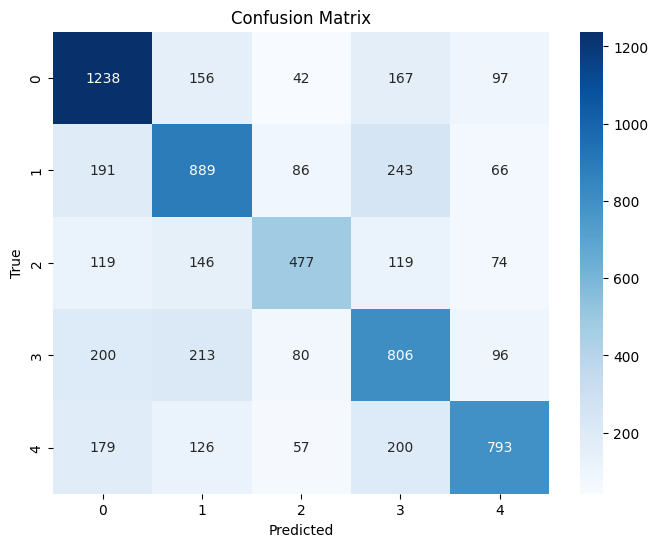

In [30]:
# K-fold cross-validation
model_trained = k_fold_cross_validation(model, video_features, video_labels, num_folds=num_folds, batch_size=batch_size, num_epochs=num_epochs, learning_rate=lr, device=device)

# **Extract Embeddings**

In [12]:
model_trained = model.to(device).float()  # Ensure model is in Float
model_trained.eval()  # Set the model to evaluation mode

VideoEmotionRNN(
  (lstm): LSTM(512, 256, num_layers=4, batch_first=True, dropout=0.3)
  (fc_out): Linear(in_features=256, out_features=5, bias=True)
  (softmax): Softmax(dim=1)
)

In [13]:
# Preprocess data
import os
video_features, video_labels, video_links = preprocess_data("/content/drive/MyDrive/Embedding /videos_face_embeddings_final.csv",  input_dim=input_dim)

Label encoding mapping: {np.str_('A'): 0, np.str_('H'): 1, np.str_('L'): 2, np.str_('N'): 3, np.str_('S'): 4}


In [15]:
video_features.shape

torch.Size([8575, 15, 512])

In [14]:
# Splitting and DataLoader Preparation
def prepare_data_loaders_emb(video_features, video_labels, batch_size):

    # Create datasets
    train_dataset = TensorDataset(video_features, video_labels)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)


    return train_loader

In [15]:
 # Prepare DataLoaders
data_loader = prepare_data_loaders_emb(video_features, video_labels, batch_size=batch_size)

In [16]:
all_embeddings = []
all_labels = []

with torch.no_grad():  # No need to compute gradients
    for video_features, labels in data_loader:
        video_features = video_features.to(device).float()  # Convert to Float
        labels = labels.to(device)  # Ensure labels are also on the correct device

        # Extract embeddings
        embeddings = model_trained(video_features, extract_embeddings=True)

        all_embeddings.append(embeddings.cpu().numpy())  # Move to CPU and convert to numpy
        all_labels.append(labels.cpu().numpy())  # Collect labels as well

# Concatenate embeddings and labels across all batches
all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [17]:


print("\nExtracted Embeddings Shape:", all_embeddings.shape)
print("Targets Shape:", all_labels.shape)


Extracted Embeddings Shape: (8575, 256)
Targets Shape: (8575,)


In [26]:
all_embeddings

array([[ 0.55410683, -0.01632102, -0.04713834, ...,  0.28342375,
        -0.6963141 , -0.00242115],
       [ 0.54857725, -0.00657728,  0.3676334 , ...,  0.20814863,
        -0.6087653 , -0.00321252],
       [ 0.5099086 , -0.00817693,  0.4364478 , ...,  0.18466407,
        -0.6984172 , -0.00136716],
       ...,
       [-0.05506656,  0.45388922,  0.11042622, ..., -0.346034  ,
        -0.0041766 , -0.7524526 ],
       [-0.12375136,  0.55476207,  0.04870281, ..., -0.4404649 ,
        -0.00178526, -0.6402124 ],
       [-0.06844977, -0.47819668,  0.10471996, ..., -0.33787322,
         0.45373133, -0.79393715]], dtype=float32)

In [18]:
import pandas as pd
import numpy as np

# Convert embeddings and targets to numpy arrays if they are not already
all_embeddings = np.array(all_embeddings)
all_targets = np.array(all_labels)

# Ensure that embeddings and targets have the same number of samples
assert all_embeddings.shape[0] == all_targets.shape[0], "Mismatch between number of embeddings and targets"

# Convert embeddings to DataFrame
embeddings_df = pd.DataFrame(all_embeddings)

# Add the targets and link column
embeddings_df['Target'] = all_targets
embeddings_df['Link'] = video_links

# Save the DataFrame to CSV
embeddings_df.to_csv('/content/drive/MyDrive/Embedding /embeddings_with_targets_RNN.csv', index=False)

print("\nEmbeddings and targets have been saved to 'embeddings_with_targets.csv'.")


Embeddings and targets have been saved to 'embeddings_with_targets.csv'.
